# The Linear-Nonlinear Poisson Model

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

## Introduction

The Linear-Nonlinear Poisson (LNP) Model is a statistical abstraction of spike generation, treating a neuron's spikes as a temporal point process. This model disregards the mechanics behind generation, instead describing spikes as random variables; specifically, Poisson random variables.

Later in this notebook we will explore some of the properties of Poisson spiking, but it has two properties that are characteristic of real neurons.
- The ratio of variance and mean of the spike count is close to 1.
- The interspike interval (ISI) of the spikes is approximately Exponentially distributed.

To start, we need to introduce Poisson processes.

In [2]:
# Testing LNP model
t_max = 10
dt = 0.01
num_steps  = int(t_max / dt)
time = np.arange(0, t_max, dt)

# Intensity function: sinusoidal
intensity = np.zeros(num_steps)
for i in range(num_steps):
    intensity[i] = 4 * (1 + np.sin(i / 20))

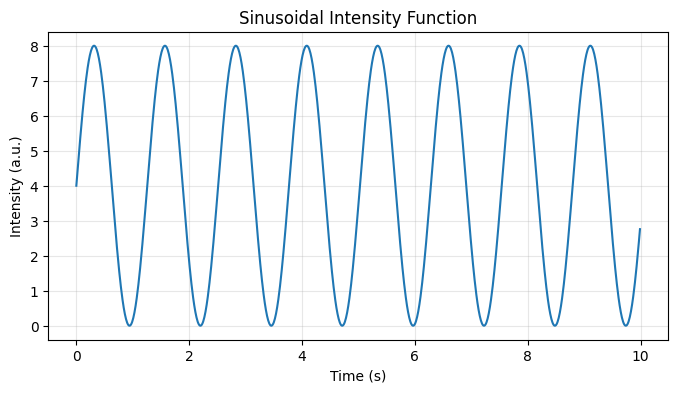

In [3]:
# Plot intensity function
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time, intensity, label="Intensity")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Intensity (a.u.)")
ax.set_title("Sinusoidal Intensity Function")
ax.grid(alpha=0.3)
plt.show()

In [4]:
# Non-homogenous Poisson Process
# This function generates spikes for one neuron time steps given an intensity using the LNP model
def generate_spikes(num_steps, dt, intensity) -> np.ndarray:
    spike_probs = np.clip(intensity * dt, 0.0, 1.0) # Bernoulli approximation for small dt
    spikes = (np.random.rand(num_steps) < spike_probs).astype(np.int8)
    return spikes

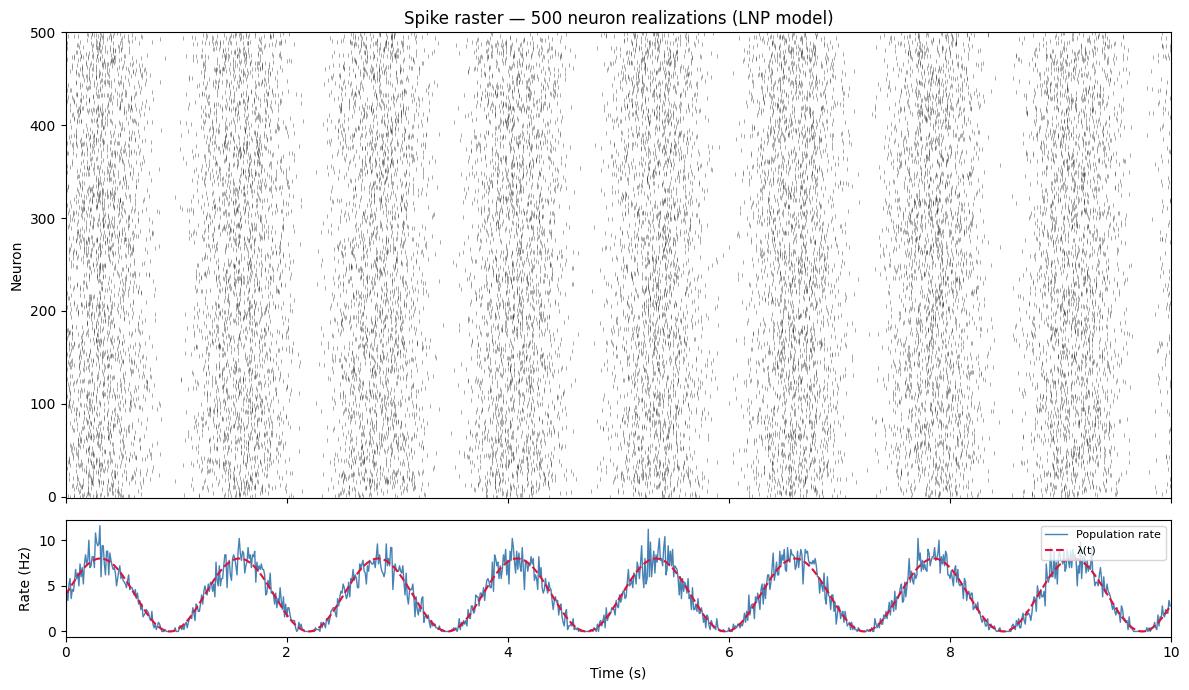

In [5]:
# 500 neuron realizations of generate_spikes, plot raster
num_neurons = 500
spike_matrix = np.array([
    generate_spikes(num_steps, dt, intensity)
    for _ in range(num_neurons)
])

# Raster plot
fig, axes = plt.subplots(2, 1, figsize=(12, 7),
                          gridspec_kw={"height_ratios": [4, 1]})

# --- Raster ---
ax = axes[0]
for neuron_idx, spike_train in enumerate(spike_matrix):
    spike_times = time[spike_train == 1]
    ax.scatter(spike_times, np.full_like(spike_times, neuron_idx),
               marker="|", s=8, c="black", linewidths=0.4, alpha=0.6)

ax.set_ylabel("Neuron")
ax.set_xlim(0, num_steps * dt)
ax.set_ylim(-1, num_neurons)
ax.set_title("Spike raster — 500 neuron realizations (LNP model)")
ax.set_xticklabels([])

# --- Population firing rate ---
ax2 = axes[1]
pop_rate = spike_matrix.sum(axis=0) / (num_neurons * dt)   # spikes/s
ax2.plot(time, pop_rate, color="steelblue", lw=1, label="Population rate")
ax2.plot(time, intensity, color="crimson", lw=1.5, linestyle="--", label="λ(t)")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Rate (Hz)")
ax2.legend(loc="upper right", fontsize=8)
ax2.set_xlim(0, num_steps * dt)

plt.tight_layout()
plt.show()